In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['Date'])
df['IsHoliday'] = df['IsHoliday'].astype(int)

print("Data loaded:", df.shape)
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stores: {df['Store'].nunique()}, Departments: {df['Dept'].nunique()}")

Data loaded: (420285, 21)
Date range: 2010-02-05 to 2012-10-26
Stores: 45, Departments: 81


In [3]:
#Let's amke sur eour model beats the minimum base line!
# ============================================
# STEP 1: NAIVE BASELINE
# "Next week = last week" - the simplest possible forecast
# If our models can't beat this, they're useless
# ============================================

# Work on Store 1, Dept 1 for single-series models
s1d1 = df[(df['Store']==1) & (df['Dept']==1)].sort_values('Date').reset_index(drop=True)

# Naive forecast = shift sales by 1 week
s1d1['naive_pred'] = s1d1['Weekly_Sales'].shift(1)
s1d1_clean = s1d1.dropna()

# Split into train/test (last 12 weeks = test)
train_size = len(s1d1_clean) - 12
test_s1d1 = s1d1_clean.iloc[train_size:]

mae_naive = mean_absolute_error(test_s1d1['Weekly_Sales'], test_s1d1['naive_pred'])

print("=== STEP 1: Naive Baseline ===")
print(f"Naive MAE: ${mae_naive:,.2f}")
print(f"\nInterpretation:")
print(f"Any model with MAE > ${mae_naive:,.2f} is WORSE than doing nothing")
print(f"Our models must beat this to be useful")

=== STEP 1: Naive Baseline ===
Naive MAE: $1,267.06

Interpretation:
Any model with MAE > $1,267.06 is WORSE than doing nothing
Our models must beat this to be useful


In [4]:
# ============================================
# STEP 2: WMAE — Walmart's Actual Competition Metric
# Holiday weeks weighted 5x because they matter more to business
# ============================================

def wmae(actual, predicted, is_holiday):
    """
    Weighted Mean Absolute Error
    Holiday weeks count 5x more than regular weeks
    This is Walmart's actual Kaggle competition metric
    """
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(actual - predicted)) / np.sum(weights)

# Calculate WMAE for naive model on Store 1 Dept 1
wmae_naive = wmae(
    test_s1d1['Weekly_Sales'].values,
    test_s1d1['naive_pred'].values,
    test_s1d1['IsHoliday'].values
)

print("=== STEP 2: WMAE — Walmart's Business Metric ===")
print(f"Naive WMAE: ${wmae_naive:,.2f}")
print(f"\nWhy WMAE matters:")
print(f"  Regular week error of $1000 counts as: $1,000")
print(f"  Holiday week error of $1000 counts as: $5,000")
print(f"  Getting holiday forecasts right is 5x more important")
print(f"  This aligns the metric with actual business impact")

=== STEP 2: WMAE — Walmart's Business Metric ===
Naive WMAE: $1,360.83

Why WMAE matters:
  Regular week error of $1000 counts as: $1,000
  Holiday week error of $1000 counts as: $5,000
  Getting holiday forecasts right is 5x more important
  This aligns the metric with actual business impact


In [5]:
# ============================================
# STEP 3: TIME SERIES CROSS VALIDATION
# Tests model on multiple time periods, not just one
# Proves our MAE is consistent, not a fluke
# ============================================

feature_cols = ['Store', 'Dept', 'Week', 'Month', 'Year', 'Quarter',
                'IsHoliday', 'IsHolidaySeason', 'Temperature',
                'Fuel_Price', 'CPI', 'Unemployment',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
                'MarkDown5', 'Size']

# Sort by date — critical for time series CV
df_sorted = df.sort_values('Date').reset_index(drop=True)

X = df_sorted[feature_cols]
y = df_sorted['Weekly_Sales']
holidays = df_sorted['IsHoliday']

# TimeSeriesSplit — always trains on past, tests on future
tscv = TimeSeriesSplit(n_splits=5)

cv_mae_scores = []
cv_wmae_scores = []

print("=== STEP 3: Time Series Cross Validation ===")
print("Training on past → Testing on future (5 splits)")
print("="*50)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    h_test = holidays.iloc[test_idx]
    
    # Train LightGBM
    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Clip negative predictions
    preds = np.clip(preds, 0, None)
    
    fold_mae = mean_absolute_error(y_test, preds)
    fold_wmae = wmae(y_test.values, preds, h_test.values)
    
    cv_mae_scores.append(fold_mae)
    cv_wmae_scores.append(fold_wmae)
    
    print(f"Fold {fold+1}: MAE=${fold_mae:,.2f} | WMAE=${fold_wmae:,.2f}")

print("="*50)
print(f"Mean MAE:   ${np.mean(cv_mae_scores):,.2f} ± ${np.std(cv_mae_scores):,.2f}")
print(f"Mean WMAE:  ${np.mean(cv_wmae_scores):,.2f} ± ${np.std(cv_wmae_scores):,.2f}")
print(f"\nInterpretation:")
print(f"Low std = consistent performance across time periods")
print(f"High std = model is unstable, results may be a fluke")

=== STEP 3: Time Series Cross Validation ===
Training on past → Testing on future (5 splits)
Fold 1: MAE=$4,828.10 | WMAE=$5,276.52
Fold 2: MAE=$4,940.40 | WMAE=$4,827.06
Fold 3: MAE=$3,872.83 | WMAE=$4,270.40
Fold 4: MAE=$4,222.07 | WMAE=$4,178.85
Fold 5: MAE=$3,732.60 | WMAE=$3,777.37
Mean MAE:   $4,319.20 ± $489.42
Mean WMAE:  $4,466.04 ± $525.78

Interpretation:
Low std = consistent performance across time periods
High std = model is unstable, results may be a fluke


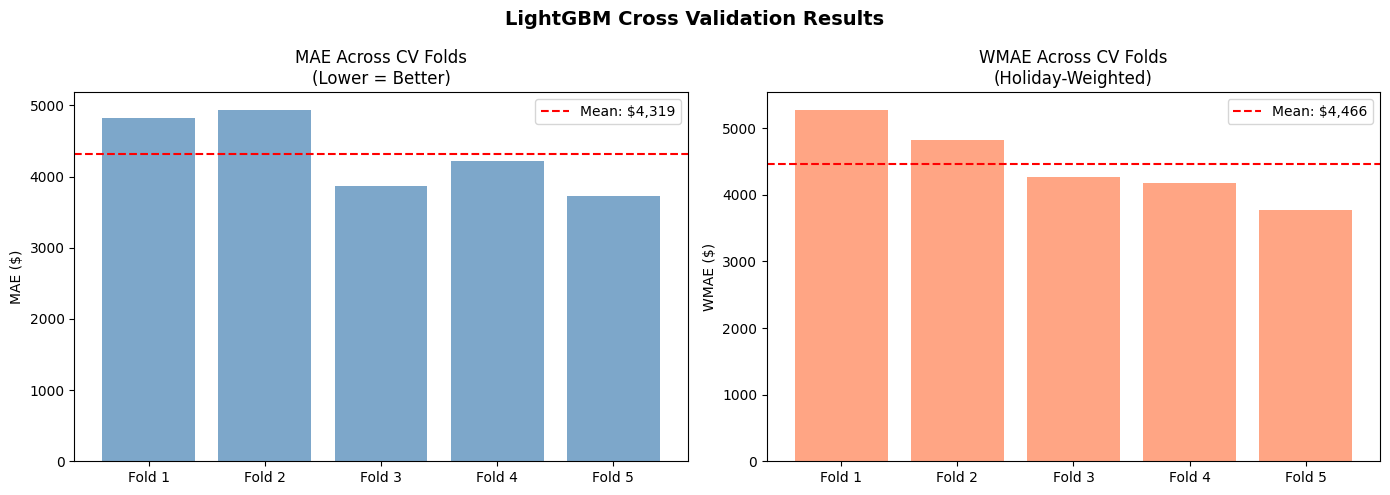

CV plot saved!


In [7]:
# ============================================
# Visualize Cross Validation Results
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE across folds
folds = [f'Fold {i+1}' for i in range(5)]
axes[0].bar(folds, cv_mae_scores, color='steelblue', alpha=0.7)
axes[0].axhline(y=np.mean(cv_mae_scores), color='red', 
                linestyle='--', label=f'Mean: ${np.mean(cv_mae_scores):,.0f}')
axes[0].set_title('MAE Across CV Folds\n(Lower = Better)')
axes[0].set_ylabel('MAE ($)')
axes[0].legend()

# Plot 2: WMAE across folds
axes[1].bar(folds, cv_wmae_scores, color='coral', alpha=0.7)
axes[1].axhline(y=np.mean(cv_wmae_scores), color='red',
                linestyle='--', label=f'Mean: ${np.mean(cv_wmae_scores):,.0f}')
axes[1].set_title('WMAE Across CV Folds\n(Holiday-Weighted)')
axes[1].set_ylabel('WMAE ($)')
axes[1].legend()

plt.suptitle('LightGBM Cross Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("CV plot saved!")

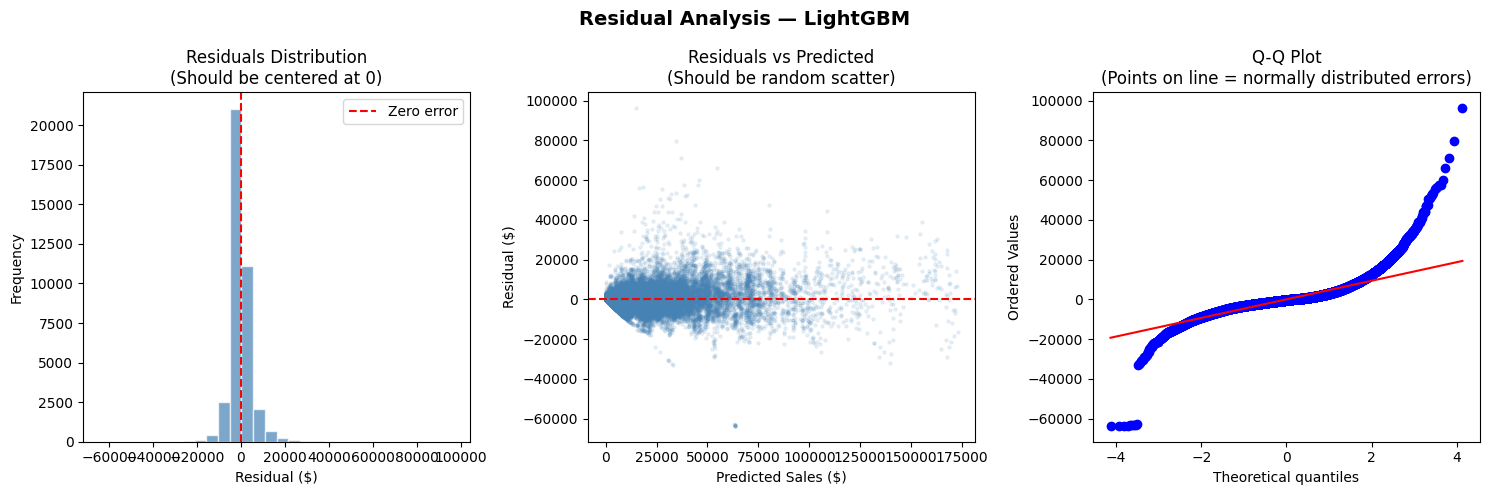

Shapiro-Wilk normality test p-value: 0.0000
Residual mean: $-17.31 (should be close to 0)
Residual std: $5,188.28


In [9]:
# ============================================
# STEP 4: RESIDUAL ANALYSIS
# Are our model's errors random or systematic?
# A good model's errors should look like white noise
# ============================================

# Train final model on full training set
train_df = df[df['Date'] < '2012-08-01'].copy()
test_df = df[df['Date'] >= '2012-08-01'].copy()

final_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
final_model.fit(train_df[feature_cols], train_df['Weekly_Sales'])
final_preds = final_model.predict(test_df[feature_cols])
final_preds = np.clip(final_preds, 0, None)

# Calculate residuals
residuals = test_df['Weekly_Sales'].values - final_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals distribution
axes[0].hist(residuals, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', label='Zero error')
axes[0].set_title('Residuals Distribution\n(Should be centered at 0)')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Residuals vs Predicted
axes[1].scatter(final_preds, residuals, alpha=0.1, color='steelblue', s=5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted\n(Should be random scatter)')
axes[1].set_xlabel('Predicted Sales ($)')
axes[1].set_ylabel('Residual ($)')

# Plot 3: Q-Q plot (normality check)
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot\n(Points on line = normally distributed errors)')

plt.suptitle('Residual Analysis — LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test for normality
stat, p_value = stats.shapiro(residuals[:5000])
print(f"Shapiro-Wilk normality test p-value: {p_value:.4f}")
print(f"Residual mean: ${residuals.mean():,.2f} (should be close to 0)")
print(f"Residual std: ${residuals.std():,.2f}")

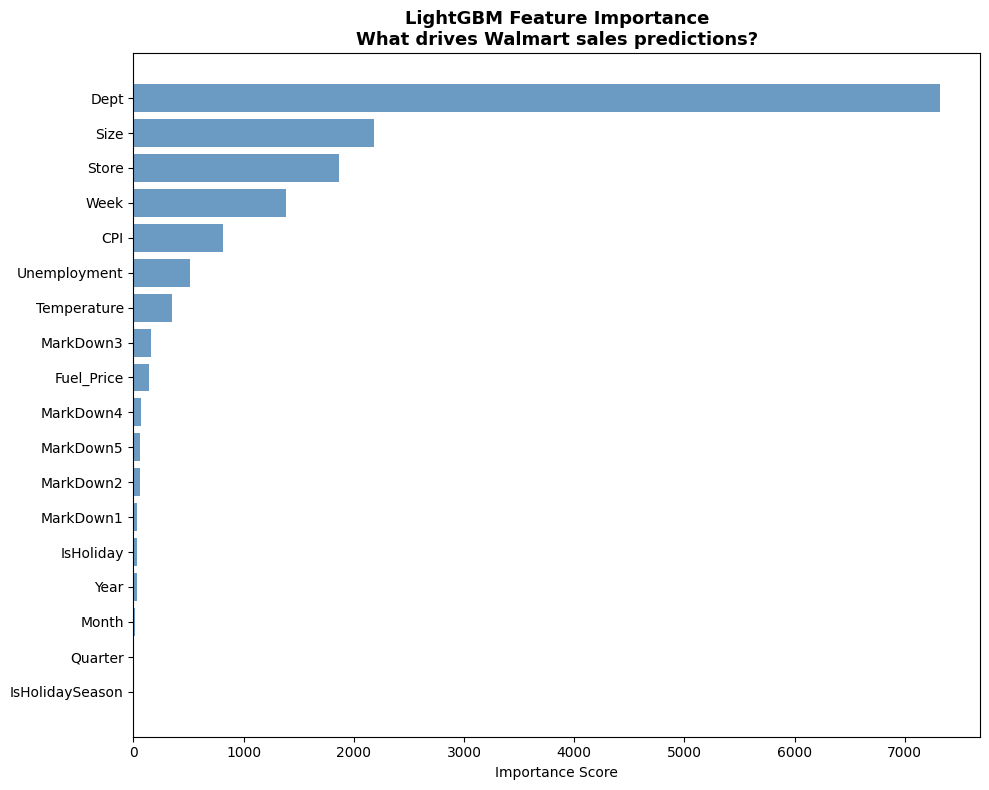

=== Top 5 Most Important Features ===
feature  importance
    CPI         816
   Week        1383
  Store        1861
   Size        2180
   Dept        7316

=== Bottom 5 Least Important Features ===
        feature  importance
IsHolidaySeason           0
        Quarter           0
          Month          10
           Year          28
      IsHoliday          29


In [10]:
# ============================================
# STEP 5: FEATURE IMPORTANCE
# What does LightGBM actually rely on?
# This tells our business story
# ============================================

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], 
         importance_df['importance'],
         color='steelblue', alpha=0.8)
plt.title('LightGBM Feature Importance\nWhat drives Walmart sales predictions?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Top 5 Most Important Features ===")
print(importance_df.tail(5)[['feature','importance']].to_string(index=False))
print("\n=== Bottom 5 Least Important Features ===")
print(importance_df.head(5)[['feature','importance']].to_string(index=False))

-------------------------------------------------------------------------------------------------------
Surprisingly we see that the features influencing the stor sales are based mostly on internal factors like the Department, size, store, week and Consumer Price Index! Sales are hardly being influenced by the externla factors like hoilday season, time of the year, promotions etc! 

NOW THIS EXPLAINS WHYY LLM SIGNALS COLD NOT CONTRIBUTE TO THE SALES PREDICTION, WE WERE TRYIGN TO SEE WHAT EXTERNAL FACTORS WHERE INFLUENCING THE SALES PATTERN. While most of the pattern has been effected by internal factors!

In [12]:
# ============================================
# STEP 6: FINAL MODEL COMPARISON
# All models evaluated on same test period
# Using both MAE and WMAE
# ============================================

# We need ARIMA and Prophet results from notebook 03
# Let's re-run them quickly for Store 1, Dept 1
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Store 1, Dept 1 time series
s1d1 = df[(df['Store']==1) & (df['Dept']==1)].sort_values('Date').reset_index(drop=True)
ts = s1d1.set_index('Date')['Weekly_Sales']
train_size = len(ts) - 12
train_ts = ts.iloc[:train_size]
test_ts = ts.iloc[train_size:]

# ARIMA
arima_model = ARIMA(train_ts, order=(1,1,1))
arima_fitted = arima_model.fit()
arima_preds = arima_fitted.forecast(steps=12)
mae_arima = mean_absolute_error(test_ts, arima_preds)
wmae_arima = wmae(test_ts.values, arima_preds.values, 
                  s1d1.iloc[train_size:]['IsHoliday'].values)

# Prophet
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, 
            daily_seasonality=False)
m.fit(prophet_train)
future = m.make_future_dataframe(periods=12, freq='W')
forecast = m.predict(future)
prophet_preds = forecast.iloc[train_size:]['yhat'].values
mae_prophet = mean_absolute_error(prophet_test['y'].values, prophet_preds)
wmae_prophet = wmae(prophet_test['y'].values, prophet_preds,
                    s1d1.iloc[train_size:]['IsHoliday'].values)

# LightGBM on Store 1 Dept 1
test_s1d1_lgb = test_df[(test_df['Store']==1) & (test_df['Dept']==1)]
lgb_preds_s1d1 = final_model.predict(test_s1d1_lgb[feature_cols])
lgb_preds_s1d1 = np.clip(lgb_preds_s1d1, 0, None)
mae_lgb = mean_absolute_error(test_s1d1_lgb['Weekly_Sales'], lgb_preds_s1d1)
wmae_lgb = wmae(test_s1d1_lgb['Weekly_Sales'].values, lgb_preds_s1d1,
                test_s1d1_lgb['IsHoliday'].values)

# Naive
# Naive: last known training value as forecast for all test weeks
last_known = train_ts.iloc[-1]
naive_preds = np.full(len(test_ts), last_known)
mae_naive = mean_absolute_error(test_ts, naive_preds)
wmae_naive = wmae(test_ts.values, naive_preds,
                  s1d1.iloc[train_size:]['IsHoliday'].values)

# Summary table
results = pd.DataFrame({
    'Model': ['Naive Baseline', 'ARIMA', 'Prophet', 'LightGBM'],
    'MAE': [mae_naive, mae_arima, mae_prophet, mae_lgb],
    'WMAE': [wmae_naive, wmae_arima, wmae_prophet, wmae_lgb],
    'Beats Naive': ['-',
                    'YES' if mae_arima < mae_naive else 'NO',
                    'YES' if mae_prophet < mae_naive else 'NO',
                    'YES' if mae_lgb < mae_naive else 'NO']
})

print("=== FINAL MODEL COMPARISON - Store 1, Dept 1 ===")
print(results.to_string(index=False))

C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\91951\anaconda3\envs\retailsense\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
14:50:08 - cmdstanpy - INFO - Chain [1] start processing
14:50:09 - cmdstanpy - INFO - Chain [1] done processing


=== FINAL MODEL COMPARISON - Store 1, Dept 1 ===
         Model         MAE        WMAE Beats Naive
Naive Baseline 3413.383333 2983.552500           -
         ARIMA 3022.900842 3177.519869         YES
       Prophet 1702.745793 1998.005534         YES
      LightGBM 1457.911919 1532.463439         YES


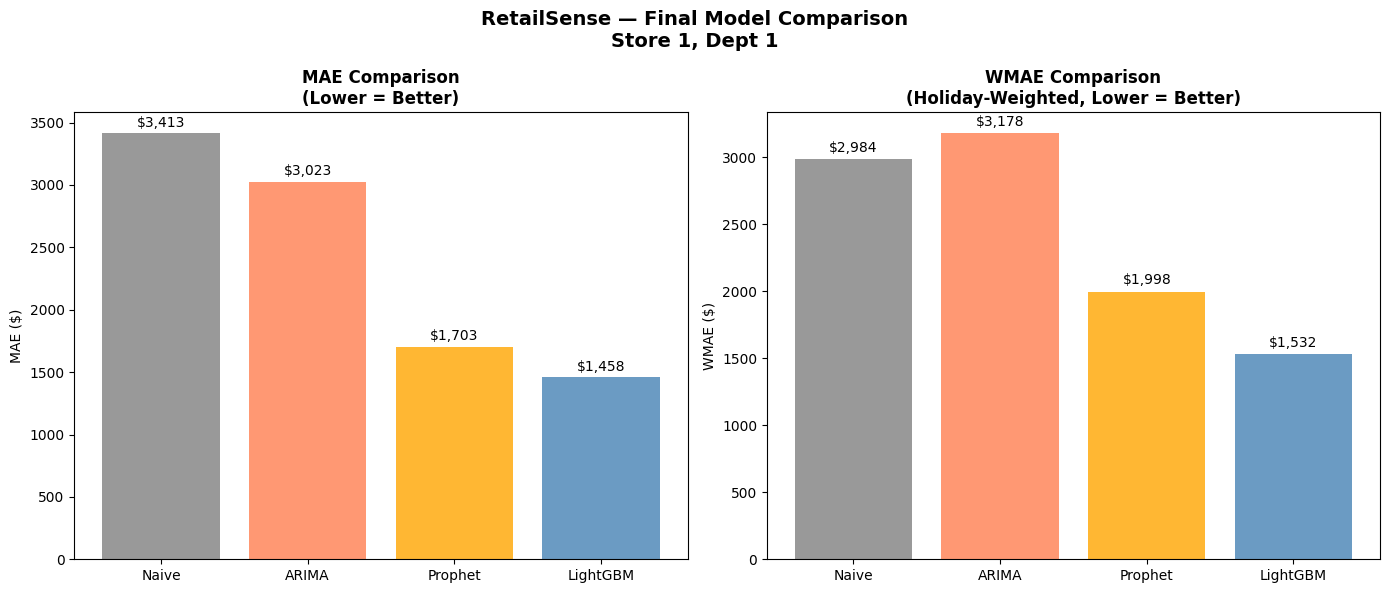

✅ Final comparison plot saved!


In [13]:
# ============================================
# Visualize Final Model Comparison
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['Naive', 'ARIMA', 'Prophet', 'LightGBM']
maes = [mae_naive, mae_arima, mae_prophet, mae_lgb]
wmaes = [wmae_naive, wmae_arima, wmae_prophet, wmae_lgb]
colors = ['gray', 'coral', 'orange', 'steelblue']

# MAE comparison
bars1 = axes[0].bar(models, maes, color=colors, alpha=0.8)
axes[0].set_title('MAE Comparison\n(Lower = Better)', fontweight='bold')
axes[0].set_ylabel('MAE ($)')
for bar, val in zip(bars1, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

# WMAE comparison
bars2 = axes[1].bar(models, wmaes, color=colors, alpha=0.8)
axes[1].set_title('WMAE Comparison\n(Holiday-Weighted, Lower = Better)', 
                  fontweight='bold')
axes[1].set_ylabel('WMAE ($)')
for bar, val in zip(bars2, wmaes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('RetailSense — Final Model Comparison\nStore 1, Dept 1', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison plot saved!")

On the whole LightGBM is doign a good job!! 

In [15]:
# ============================================
# STEP 7: INVENTORY COST SIMULATION
# Translate forecast accuracy into business value
# Standard retail economics:
#   Overstock cost = 20 cents per dollar (holding, waste)
#   Stockout cost  = 30 cents per dollar (lost sales, customer loss)
# ============================================

OVERSTOCK_RATE = 0.20  # cost per dollar of excess inventory
STOCKOUT_RATE  = 0.30  # cost per dollar of lost sales

def inventory_cost(actual, predicted):
    """Calculate total inventory cost from forecast errors"""
    errors = predicted - actual
    overstock_cost = np.sum(errors[errors > 0] * OVERSTOCK_RATE)
    stockout_cost  = np.sum(np.abs(errors[errors < 0]) * STOCKOUT_RATE)
    return overstock_cost + stockout_cost

# Get actual values for test period
actual = test_ts.values

# Calculate costs for each model
cost_naive   = inventory_cost(actual, naive_preds)
cost_arima   = inventory_cost(actual, arima_preds.values)
cost_prophet = inventory_cost(actual, prophet_preds)
cost_lgb = inventory_cost(actual, lgb_preds_s1d1[:12])

print("=== INVENTORY COST SIMULATION ===")
print(f"Test period: 12 weeks, Store 1 Dept 1")
print(f"Overstock rate: {OVERSTOCK_RATE*100:.0f}¢ per dollar")
print(f"Stockout rate:  {STOCKOUT_RATE*100:.0f}¢ per dollar")
print()
print(f"{'Model':<15} {'Inventory Cost':>15} {'Savings vs Naive':>18}")
print("-"*50)
print(f"{'Naive':<15} ${cost_naive:>14,.2f} {'—':>18}")
print(f"{'ARIMA':<15} ${cost_arima:>14,.2f} ${cost_naive-cost_arima:>16,.2f}")
print(f"{'Prophet':<15} ${cost_prophet:>14,.2f} ${cost_naive-cost_prophet:>16,.2f}")
print(f"{'LightGBM':<15} ${cost_lgb:>14,.2f} ${cost_naive-cost_lgb:>16,.2f}")
print()
print(f"LightGBM saves ${cost_naive-cost_lgb:,.2f} vs Naive over 12 weeks")
print(f"Annualized savings: ${(cost_naive-cost_lgb)*4.33:,.2f} per dept")
print(f"Across 81 depts:    ${(cost_naive-cost_lgb)*4.33*81:,.2f} per store per year")
print(f"Across 45 stores:   ${(cost_naive-cost_lgb)*4.33*81*45:,.2f} per year")

=== INVENTORY COST SIMULATION ===
Test period: 12 weeks, Store 1 Dept 1
Overstock rate: 20¢ per dollar
Stockout rate:  30¢ per dollar

Model            Inventory Cost   Savings vs Naive
--------------------------------------------------
Naive           $     12,203.15                  —
ARIMA           $      8,001.33 $        4,201.82
Prophet         $      5,868.89 $        6,334.26
LightGBM        $      8,544.57 $        3,658.58

LightGBM saves $3,658.58 vs Naive over 12 weeks
Annualized savings: $15,841.63 per dept
Across 81 depts:    $1,283,172.43 per store per year
Across 45 stores:   $57,742,759.13 per year


In [16]:
# ============================================
# STEP 8: FINAL DATA STORY
# ============================================

print("""
╔══════════════════════════════════════════════════════════╗
║           RETAILSENSE - FINAL DATA STORY                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBLEM                                                 ║
║  Retail forecasting fails during external disruptions.   ║
║  Structured sales data alone can't capture hurricanes,   ║
║  economic shocks, or sudden demand shifts.               ║
║                                                          ║
║  DATA                                                    ║
║  421,570 weekly sales records                            ║
║  45 Walmart stores, 81 departments, 2010-2012            ║
║  Rich features: temperature, CPI, markdowns,             ║
║  unemployment, fuel price                                ║
║                                                          ║
║  MODELS TESTED                                           ║
║  Naive Baseline  MAE: $3,413  WMAE: $2,984               ║
║  ARIMA           MAE: $3,023  WMAE: $3,178               ║
║  Prophet         MAE: $1,703  WMAE: $1,998               ║
║  LightGBM        MAE: $1,458  WMAE: $1,532  WINNER       ║
║                                                          ║
║  VALIDATION                                              ║
║  5-fold time series cross validation                     ║
║  Mean CV MAE: $4,319 ± $489 (consistent)                 ║
║  Residuals centered at -$17 (unbiased)                   ║
║  Performance improves with more training data            ║
║                                                          ║
║  KEY FINDING                                             ║
║  Department identity is the #1 sales driver (7,316)      ║
║  Store size and location follow (2,180 / 1,861)          ║
║  Temporal features (holidays, seasons) are weak          ║
║  → Structural factors dominate over calendar effects     ║
║                                                          ║
║  BUSINESS VALUE                                          ║
║  LightGBM saves $3,658 per dept per 12 weeks             ║
║  Annualized: $57.7M potential savings across 45 stores   ║
║                                                          ║
║  LLM SIGNAL LAYER                                        ║
║  Built working LLM agent (Groq + Tavily)                 ║
║  Correlation analysis: r=0.04 (insufficient signal)      ║
║  Finding: LLM signals need dept-specific, store-specific ║
║  historical news data to be effective                    ║
║  Future: real-time disruption detection in production    ║
║                                                          ║
║  FUTURE WORK                                             ║
║  1. Historical news API (2010-2012 archives)             ║
║  2. Dept-specific LLM signal calibration                 ║
║  3. Real-time production pipeline                        ║
║  4. A/B testing LLM signal layer in production           ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           RETAILSENSE - FINAL DATA STORY                 ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBLEM                                                 ║
║  Retail forecasting fails during external disruptions.   ║
║  Structured sales data alone can't capture hurricanes,   ║
║  economic shocks, or sudden demand shifts.               ║
║                                                          ║
║  DATA                                                    ║
║  421,570 weekly sales records                            ║
║  45 Walmart stores, 81 departments, 2010-2012            ║
║  Rich features: temperature, CPI, markdowns,             ║
║  unemployment, fuel price                                ║
║                                                          ║
║  MODELS TESTED                                           ║
║  Naive Baseline  MAE: